**Geração de pontos 2D usando umadistribuição Gaussiana multivariada**

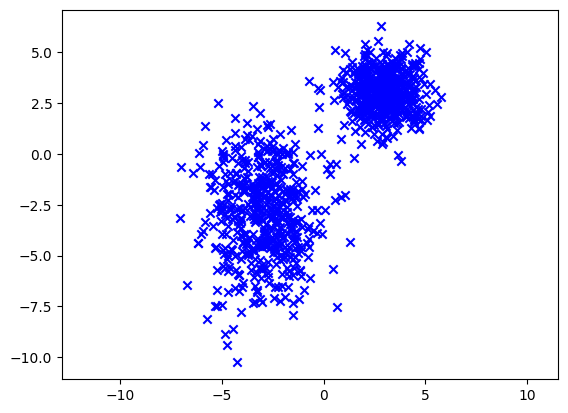

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

mean = [3, 3]
cov = [[1 , 0], [0, 1]]
a = np.random.multivariate_normal(mean, cov, 500).T
mean = [-3, -3]
cov = [[2 , 0], [0, 5]]
b = np.random.multivariate_normal(mean, cov, 500).T
c = np.concatenate((a, b) , axis = 1)
c = c.T
etiqueta_a = np.ones((a.shape[1], 1))
etiqueta_b = np.full((b.shape[1], 1), 2)
etiquetas = np.vstack((etiqueta_a, etiqueta_b))
c = np.hstack((c, etiquetas))
np.random. shuffle(c)
c = c.T
x = c[0]
y = c[1]
etiquetas = c[2]
plt.scatter(x, y, c='blue', marker='x')
plt.axis ( 'equal' )
plt.show()
np.savetxt('conjunto_de_etiquetas.txt', c.T, fmt='%.3f', delimiter=',', header='x,y,etiqueta', comments='')

**Implementação do algoritmo K-Means (1.2)**

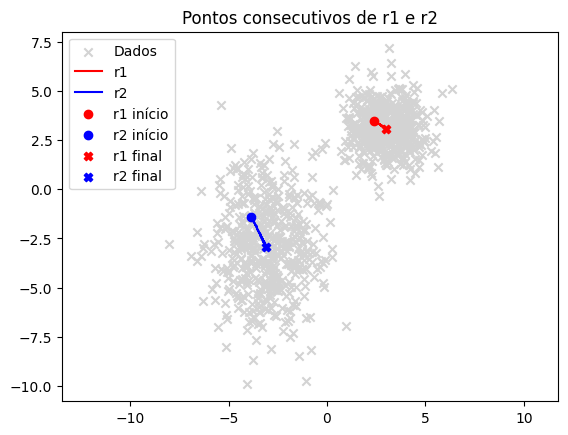

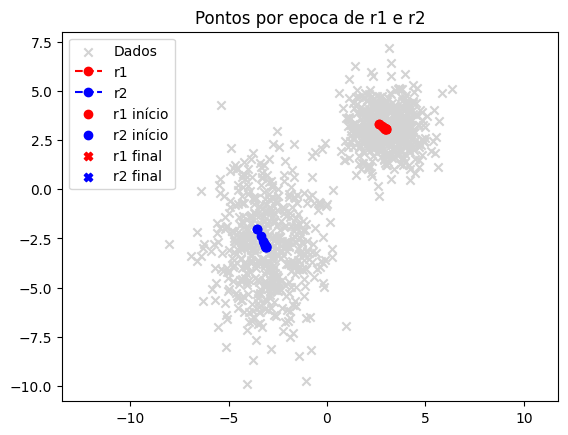

In [159]:
import matplotlib.pyplot as plt
import numpy as np
import random

pontos = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
coordenadas= pontos[:, 0:2]

r1 = coordenadas[random.randint(0 , len(coordenadas)-1)]
r2 = coordenadas[random.randint(0 , len(coordenadas)-1)]

alpha = 0.001
num_epocas = 10

r1_update = []
r2_update = []
r1_final = []
r2_final = []

for epoca in range(num_epocas):
    for x in coordenadas:
        d1 = np.sqrt(np.sum((x-r1) ** 2))
        d2 = np.sqrt(np.sum((x-r2) ** 2))

        if d1 < d2:
            r1 = (1-alpha) * r1 + alpha * x
            r1_update.append(r1.copy())
        else:
            r2 = (1-alpha) * r2 + alpha * x
            r2_update.append(r2.copy())
    r1_final.append(r1.copy())
    r2_final.append(r2.copy())

r1_update = np.array(r1_update)
r2_update = np.array(r2_update)
r1_final = np.array(r1_final)
r2_final = np.array(r2_final)

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='x', label='Dados')
plt.plot(r1_update[:,0], r1_update[:,1], 'r-', label='r1')
plt.plot(r2_update[:,0], r2_update[:,1], 'b-', label='r2')
plt.scatter(r1_update[0,0], r1_update[0,1], c='red', marker='o', label='r1 início')
plt.scatter(r2_update[0,0], r2_update[0,1], c='blue', marker='o', label='r2 início')
plt.scatter(r1_update[-1,0], r1_update[-1,1], c='red', marker='X', label='r1 final')
plt.scatter(r2_update[-1,0], r2_update[-1,1], c='blue', marker='X', label='r2 final')
plt.title("Pontos consecutivos de r1 e r2")
plt.legend()
plt.axis('equal')
plt.show()

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='x', label='Dados')
plt.plot(r1_final[:,0], r1_final[:,1], 'ro--', label='r1')
plt.plot(r2_final[:,0], r2_final[:,1], 'bo--', label='r2')
plt.scatter(r1_final[0,0], r1_final[0,1], c='red', marker='o', label='r1 início')
plt.scatter(r2_final[0,0], r2_final[0,1], c='blue', marker='o', label='r2 início')
plt.scatter(r1_final[-1,0], r1_final[-1,1], c='red', marker='X', label='r1 final')
plt.scatter(r2_final[-1,0], r2_final[-1,1], c='blue', marker='X', label='r2 final')
plt.title("Pontos por epoca de r1 e r2")
plt.legend()
plt.axis('equal')
plt.show()
    


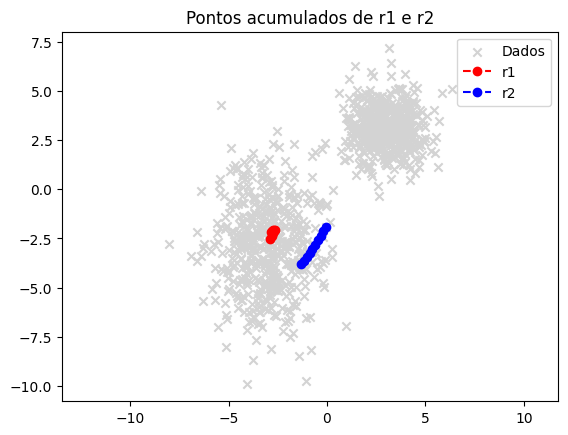

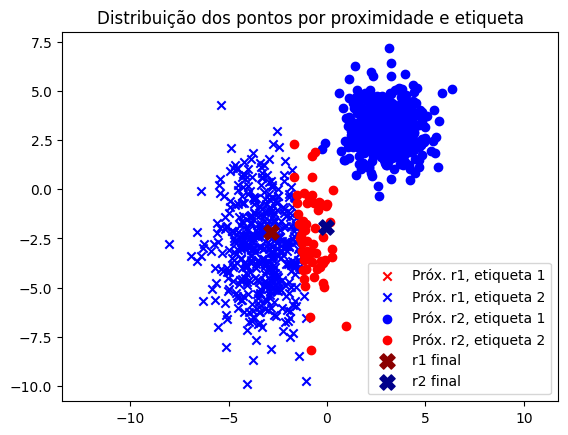

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

pontos = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
coordenadas= pontos[:, 0:2]
etiquetas = pontos[:, 2]

r1 = coordenadas[random.randint(0 , len(coordenadas)-1)]
r2 = coordenadas[random.randint(0 , len(coordenadas)-1)]

alpha = 0.05
num_epocas = 10


r1_acc = []
r2_acc = []

for epoca in range(num_epocas):
    d1_total = np.zeros(2)
    d2_total = np.zeros(2)
    n1 = 0
    n2 = 0
    for x in coordenadas:
        d1 = np.sqrt(np.sum((x-r1) ** 2))
        d2 = np.sqrt(np.sum((x-r2) ** 2))

        if d1 < d2:
            d1_total += (x - r1)
            n1 += 1
        else:
            d2_total += (x - r2)
            n2 += 1

    r1 += alpha * (d1_total / n1)
    r2 += alpha * (d2_total / n2)        
    r1_acc.append(r1.copy())
    r2_acc.append(r2.copy())


r1_acc = np.array(r1_acc)
r2_acc = np.array(r2_acc)

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='x', label='Dados')
plt.plot(r1_acc[:,0], r1_acc[:,1], 'ro--', label='r1')
plt.plot(r2_acc[:,0], r2_acc[:,1], 'bo--', label='r2')
plt.title("Pontos acumulados de r1 e r2")
plt.legend()
plt.axis('equal')
plt.show()

dist_r1 = np.sqrt(np.sum((coordenadas-r1) ** 2, axis=1))
dist_r2 = np.sqrt(np.sum((coordenadas-r2) ** 2, axis=1))
prox_r1 = dist_r1 < dist_r2  


r1_etiqueta1 = (prox_r1) & (etiquetas == 1)
r1_etiqueta2 = (prox_r1) & (etiquetas == 2)
r2_etiqueta1 = (~prox_r1) & (etiquetas == 1)
r2_etiqueta2 = (~prox_r1) & (etiquetas == 2)


plt.scatter(coordenadas[r1_etiqueta1,0], coordenadas[r1_etiqueta1,1], c='red', marker='x', label='Próx. r1, etiqueta 1')
plt.scatter(coordenadas[r1_etiqueta2,0], coordenadas[r1_etiqueta2,1], c='blue', marker='x', label='Próx. r1, etiqueta 2')
plt.scatter(coordenadas[r2_etiqueta1,0], coordenadas[r2_etiqueta1,1], c='blue', marker='o', label='Próx. r2, etiqueta 1')
plt.scatter(coordenadas[r2_etiqueta2,0], coordenadas[r2_etiqueta2,1], c='red', marker='o', label='Próx. r2, etiqueta 2')

plt.scatter(r1[0], r1[1], c='darkred', s=120, marker='X', label='r1 final')
plt.scatter(r2[0], r2[1], c='darkblue', s=120, marker='X', label='r2 final')

plt.title("Distribuição dos pontos por proximidade e etiqueta")
plt.legend()
plt.axis('equal')
plt.show()

**Exercicio 2 - Clustering aglomerativo hierárquico**

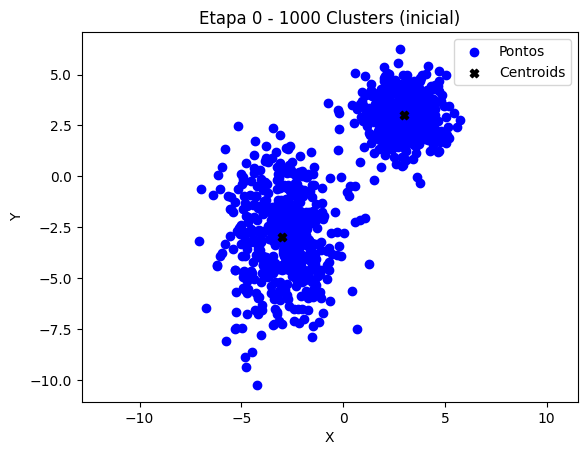

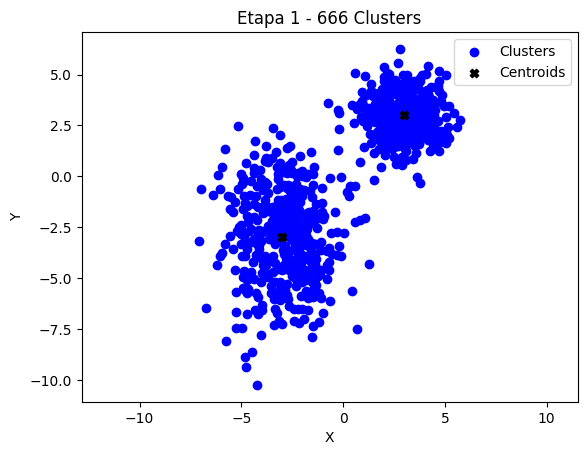

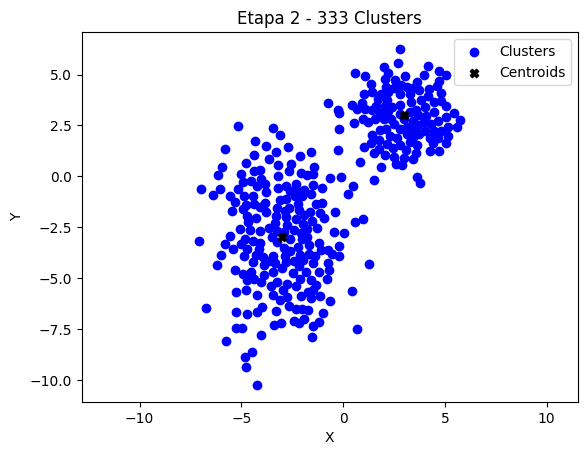

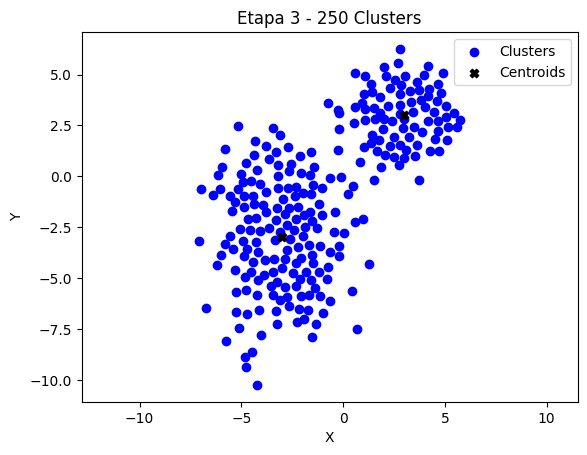

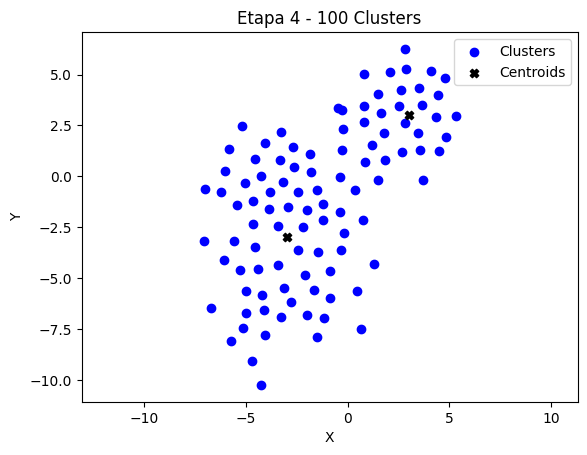

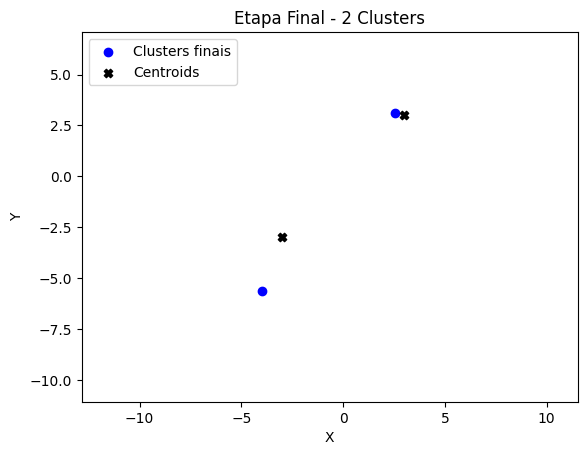

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


pontos = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
pontos_iniciais = pontos.copy() 
n_inicial = len(pontos)


marcos = [int(2*n_inicial/3), int(n_inicial/3), 250, 100]

centroids = np.array([[3,3], [-3,-3]])


plt.scatter(pontos[:,0], pontos[:,1], c='blue', label='Clusters')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', label='Centroids')
plt.axis('equal')
plt.title(f"Etapa 0 - {n_inicial} Clusters (inicial)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()


while len(pontos) > 2:
    min_dist = float('inf')
    p1, p2 = None, None
    for i in range(len(pontos)):
        for j in range(i+1, len(pontos)):
            d = np.sqrt(np.sum((pontos[i]-pontos[j])**2))
            if d < min_dist:
                min_dist = d
                p1, p2 = i, j

    novo_ponto = (pontos[p1] + pontos[p2])/2
    pontos = np.delete(pontos, [p1,p2], axis=0)
    pontos = np.vstack([pontos, novo_ponto])

    if len(pontos) in marcos:
        idx = marcos.index(len(pontos))
        plt.scatter(pontos[:,0], pontos[:,1], c='blue', label='Clusters')
        plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', label='Centroids')
        plt.axis('equal')
        plt.title(f"Etapa {idx+1} - {len(pontos)} Clusters")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.legend()
        plt.show()


plt.scatter(pontos_iniciais[:,0], pontos_iniciais[:,1], c='white', alpha=0)
plt.scatter(pontos[:,0], pontos[:,1], c='blue', label='Clusters finais')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', label='Centroids')
plt.axis('equal')
plt.title("Etapa Final - 2 Clusters")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

**Exercicio 3 - Algoritmo DBSCAN** 

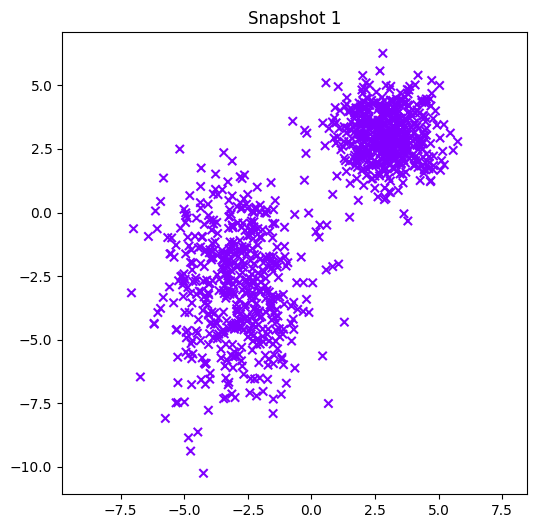

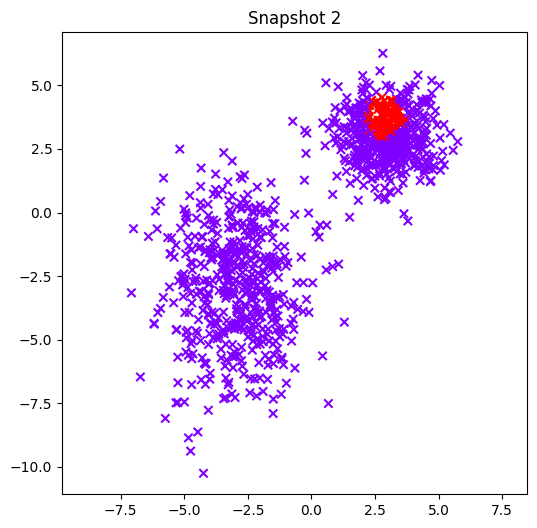

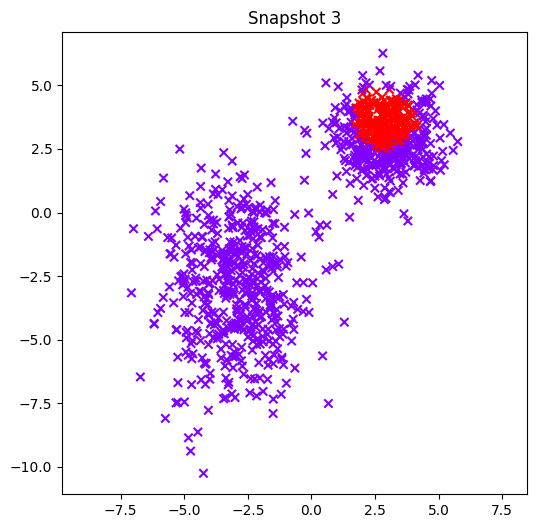

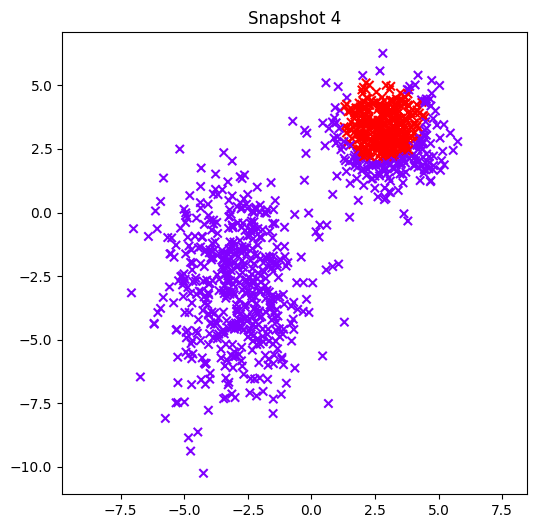

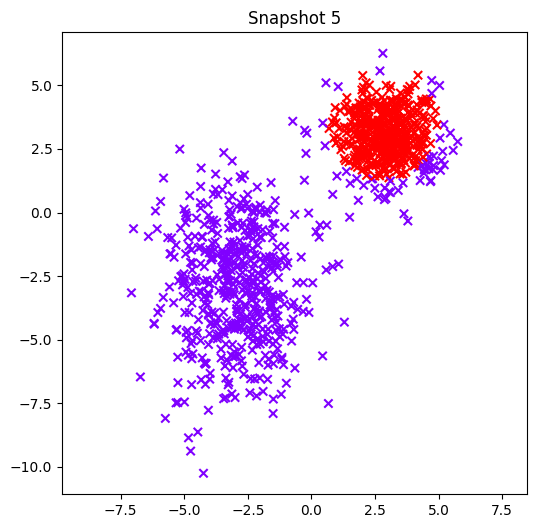

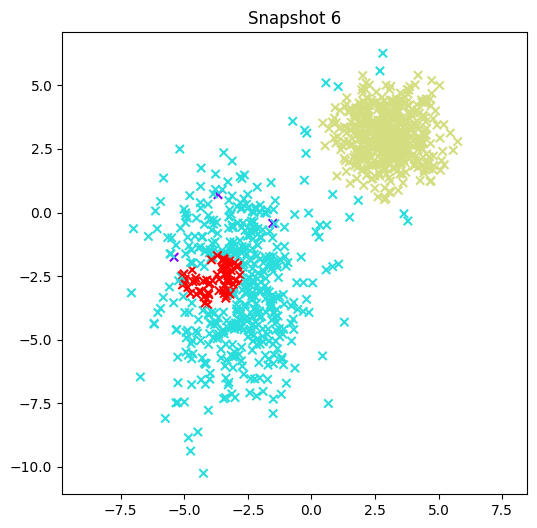

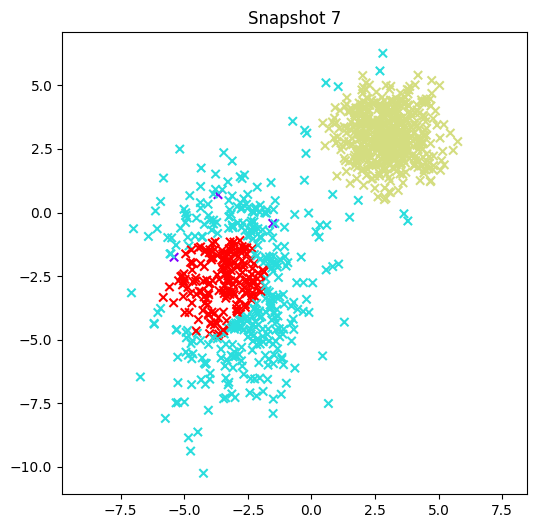

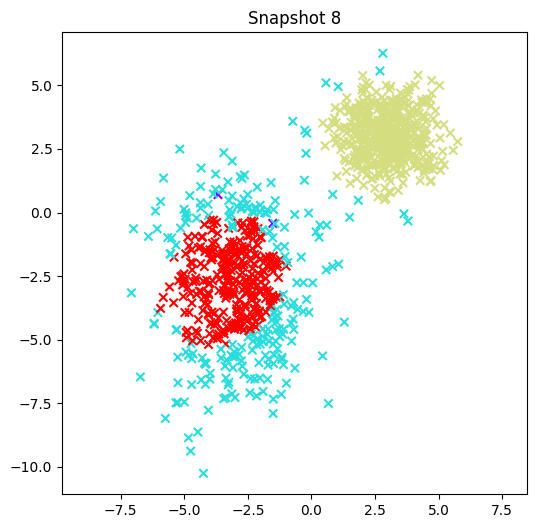

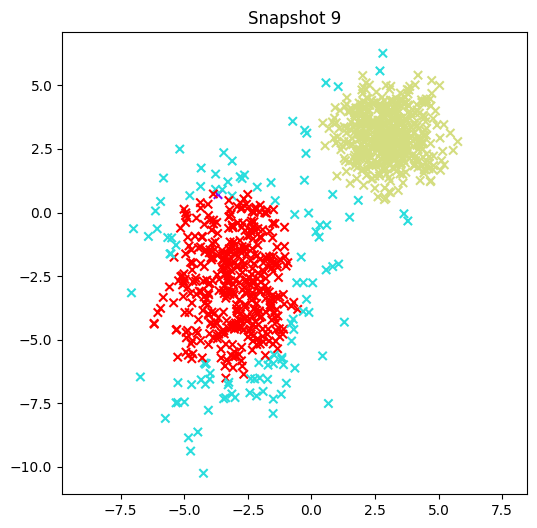

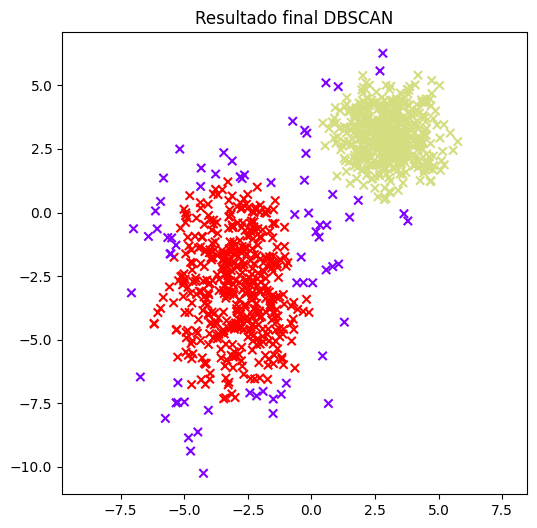

In [47]:
import numpy as np
import matplotlib.pyplot as plt


data = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
n_points = len(data)

eps = 0.5
min_samples = 10
labels = np.zeros(n_points, dtype=int)  
cluster_id = 1

num_snapshots = 10
snapshot_indices = np.linspace(0, n_points-1, num_snapshots, dtype=int)
snapshots = []
step_counter = 0 


x_min, x_max = np.min(data[:, 0]), np.max(data[:, 0])
y_min, y_max = np.min(data[:, 1]), np.max(data[:, 1])
for i in range(n_points):
    if labels[i] != 0:
        continue

    neighbors = []
    for j in range(n_points):
        if np.sqrt(np.sum((data[i] - data[j]) ** 2)) <= eps:
            neighbors.append(j)

    if len(neighbors) < min_samples:
        labels[i] = -1  
    else:
        labels[i] = cluster_id
        k = 0
        while k < len(neighbors):
            idx = neighbors[k]
            if labels[idx] == -1:
                labels[idx] = cluster_id
            elif labels[idx] == 0:
                labels[idx] = cluster_id
                for j in range(n_points):
                    if np.sqrt(np.sum((data[idx] - data[j]) ** 2)) <= eps and j not in neighbors:
                        neighbors.append(j)

            k += 1
            step_counter += 1

            
            while snapshot_indices.size > 0 and step_counter >= snapshot_indices[0]:
                snapshots.append(labels.copy())
                snapshot_indices = snapshot_indices[1:]  
                if len(snapshots) >= num_snapshots:
                    break

        cluster_id += 1

    if len(snapshots) >= num_snapshots:
        break  


for i, snapshot_labels in enumerate(snapshots):
    plt.figure(figsize=(6, 6))
    plt.scatter(data[:, 0], data[:, 1], c=snapshot_labels, cmap='rainbow', marker='x')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.axis('equal')
    plt.title(f"Snapshot {i + 1}")
    plt.show()


plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='rainbow', marker='x')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.axis('equal')
plt.title("Resultado final DBSCAN")
plt.show()